# 22 -- N=2, N=3, N=64: sledgehamr vs surrogate reconstruction overview

Six-panel summary (2 rows x 3 columns): rows are $\bar\lambda=0.84$ (top) and
$\bar\lambda=0.069$ (bottom); columns are the 2-bubble (all three $\gamma$'s
overlaid), 3-bubble, and 64-bubble cases. Each panel compares the sledgehamr
3+1D ground truth against the 1+1D surrogate reconstruction (weights x the
current production `gs1-*` runtime scan -- no dedicated 1+1D runs, no
old-scan variants, one surrogate curve per case).

The N=64, $\bar\lambda=0.069$ run's first attempt (`..._leapfrog_2048`) went
unstable partway through the collision phase (an isolated instability in one
grid cell's $du_{xz}$ component, present in every GW spectrum snapshot from
$t/R_*=1.09$ onward). Restarting from a checkpoint written just before that
point (`..._leapfrog_2048_debug`) reproduced the run cleanly all the way to
$t/R_*=2.0$ with no other changes -- so this was not a genuine physical/
numerical instability in the $\bar\lambda=0.069$ potential, but something
specific to that one continuous run (most likely non-deterministic). The
debug run is used below, with the same late-time-band comparison as the
$\bar\lambda=0.84$ panel.

The N=2 and N=3 panels reuse the same two 3-bubble sledgehamr realizations
(`bubble_N3_234_*` for $\bar\lambda=0.84$, `bubble_N3_456_*` for
$\bar\lambda=0.069$): N=2 pulls out each of the 3 pairwise sub-collisions in
isolation, N=3 is the full trio. The N=64 case is the single existing
64-bubble realization ($\bar\lambda=0.84$ only).

In [1]:
import glob
import os
import subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

import ptbuilder as pt
from ptbuilder.physics import InstantonProfile, BubbleKinematics
from ptbuilder.analysis import load_weights, load_scan, apply_keffsq, write_weights_input
from ptbuilder.ic import _cutoff_times

REPO_ROOT   = Path(pt.__file__).parent.parent
DATA_DIR    = REPO_ROOT / 'data'
SH_RUNS_DIR = REPO_ROOT / 'sledgehamr_runs'
PLOTS_DIR   = REPO_ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

# The runtime scans (data/runtime_scan_*) are large (the lb=0.84 gs1-20 scan
# alone is ~750MB across 13k+ files) and aren't pushed to git -- everything
# else this notebook needs (sledgehamr runs, weights_out_*.h5, instanton.h5)
# is small and is. SCAN_ROOT lets the scan directories live somewhere other
# than this checkout (e.g. a mounted share or a separately-downloaded
# archive) without editing this notebook -- set the PTBUILDER_SCAN_ROOT
# environment variable to override; defaults to DATA_DIR (this repo's own
# data/, the original behavior) if unset.
SCAN_ROOT = Path(os.environ.get('PTBUILDER_SCAN_ROOT', DATA_DIR))

## Shared helpers (verbatim from notebooks 05/06)

In [2]:
def _list_gw_files(sh_path):
    pattern = os.path.join(sh_path, 'gw_spectra', '*', 'spectra.hdf5')
    entries = []
    for fp in glob.glob(pattern):
        dname = os.path.basename(os.path.dirname(fp))
        if dname.isdigit():
            entries.append((int(dname), fp))
    entries.sort(key=lambda x: x[0])
    return entries


def _read_gw_file(fp):
    with h5py.File(fp, 'r') as f:
        k_int = np.asarray(f['k' if 'k' in f else 'k_sq'][:])
        spec  = np.asarray(f['Spectrum' if 'Spectrum' in f else 'spectrum'][:])
        hdr   = np.asarray(f['Header'][:]).reshape(-1)
        t     = float(hdr[0])
    return apply_keffsq(k_int), spec, t


def load_sh_all_snaps(sh_path):
    """Load all GW snapshots; returns list of (k_eff_sq, spectrum, t)."""
    files = _list_gw_files(sh_path)
    if not files:
        raise FileNotFoundError(f'No gw_spectra/*/spectra.hdf5 in {sh_path}')
    snaps = [_read_gw_file(fp) for _, fp in files]
    snaps.sort(key=lambda x: x[2])
    return snaps


def normalize_sh(k_sq, spectrum, L, zero_pad):
    """Convert raw sledgehamr spectrum to dE/dlnk on physical k axis."""
    if k_sq[0] == 0:
        k_sq     = k_sq[1:]
        spectrum = spectrum[1:]
    Leff = L * zero_pad
    r    = np.sqrt(k_sq)
    k    = r * (2 * np.pi / Leff)
    norm = 4.0 * (2 * np.pi * r) * Leff**3
    return k, spectrum * norm


def interp_sh_at_t(snaps, t_target):
    """Log-space interpolation of a snapshot list to t_target."""
    ts = np.array([s[2] for s in snaps])
    if t_target <= ts[0]:
        return snaps[0][0], snaps[0][1], ts[0]
    if t_target >= ts[-1]:
        return snaps[-1][0], snaps[-1][1], ts[-1]
    i = int(np.searchsorted(ts, t_target)) - 1
    k_sq, s_a, t_a = snaps[i]
    _,    s_b, t_b = snaps[i + 1]
    alpha = (t_target - t_a) / (t_b - t_a)
    floor = max(s_a.max(), s_b.max()) * 1e-12
    log_a = np.log(np.maximum(s_a, floor))
    log_b = np.log(np.maximum(s_b, floor))
    return k_sq, np.exp(log_a + alpha * (log_b - log_a)), t_target


def rho_vac_bar(lambda_bar):
    """False-minus-true vacuum energy in BM dimensionless units (same as
    notebooks 06/21)."""
    upsilon = 3.0 + np.sqrt(9.0 - 8.0 * lambda_bar)
    return -(0.5 - upsilon / (4.0 * lambda_bar) + upsilon**2 / (32.0 * lambda_bar))


def to_chw(dE_dlnk, rstar, lambda_bar, volume):
    """dE/dlnk -> the CHW Fig. 15 dimensionless quantity
    [H_*R_*Omega_vac]^-2 dOmega_gw/dlnk -- same formula as notebooks 06/21's
    ``energy_to_chw``/``convert_local``, so this notebook's y-axis matches
    notebook 21's."""
    return (3.0 / (8.0 * np.pi * rho_vac_bar(lambda_bar) ** 2 * rstar ** 2 * volume)) * dE_dlnk


def load_kinematics_local(lb):
    """Load BubbleKinematics from stored instanton.h5 (no C++ needed)."""
    path = DATA_DIR / f'phi4_lambda_bar{lb}' / 'instanton.h5'
    with h5py.File(path, 'r') as f:
        profile = InstantonProfile(
            R=f['R'][:], Phi=f['Phi'][:],
            rin_0 =float(f.attrs['rin_0']),
            rmid_0=float(f.attrs['rmid_0']),
            rout_0=float(f.attrs['rout_0']),
            interp=None,
        )
    return BubbleKinematics(profile)


def load_new_scan_rows(scan_dir):
    """Load an older-format manifest.tsv-indexed runtime scan (gs1-6,
    gs1-5, ... -- result_*.h5 files here carry no t/gamma_ij attrs, unlike
    the newer row_XXXX scans ptbuilder.analysis.load_scan() reads; times/w
    come from each row's own setup.h5 instead). Returns the same shape
    load_scan() does (SimpleNamespace with .rows/.gamma_min/.gamma_max/.t_max)
    so build_scan_interp_fn() works on either. Matches notebook 05's
    ``load_new_scan_rows``."""
    from types import SimpleNamespace
    scan_dir = Path(scan_dir)
    manifest_lines = (scan_dir / 'manifest.tsv').read_text().strip().split('\n')[1:]
    rows = []
    for line in manifest_lines:
        index, gamma, n_t, setup_rel, name = line.split('\t')
        setup_path = REPO_ROOT / setup_rel
        outdir = scan_dir / 'gpu' / name
        files = sorted(outdir.glob('result_*.h5'), key=lambda p: int(p.stem.split('_')[1]))
        if not files:
            continue
        with h5py.File(setup_path) as f:
            times_row = f['times'][:]
            w_row     = f['wlist'][:]
        spectrum_row = np.zeros((len(files), len(w_row)))
        for it, fp in enumerate(files):
            with h5py.File(fp) as f:
                spectrum_row[it] = f['spectrum'][:]
        rows.append(SimpleNamespace(gamma_ij=float(gamma), times=times_row[:len(files)],
                                    wlist=w_row, spectrum=spectrum_row))
    rows.sort(key=lambda r: r.gamma_ij)
    t_max = max(r.times[-1] for r in rows)
    return SimpleNamespace(rows=rows, gamma_min=rows[0].gamma_ij,
                           gamma_max=rows[-1].gamma_ij, t_max=t_max)


def build_scan_interp_fn(scan_data, k_out):
    """(gamma, t) -> spectrum[k_out] interpolator from a load_scan() result.

    Projects every row onto the shared k_out grid once, then does log-linear
    interpolation across gamma between the two bracketing rows and
    log-linear interpolation across each row's own times -- same convention
    as notebooks 05/06's ``build_new_scan_interpolator``/``new_interp_fn``,
    just built once here for reuse across all three cases.
    """
    rows   = scan_data.rows
    gammas = np.array([r.gamma_ij for r in rows])
    spec_on_kout = []
    for r in rows:
        spec_k = np.zeros((len(r.times), len(k_out)))
        for it in range(len(r.times)):
            spec_k[it] = np.interp(k_out, r.wlist, r.spectrum[it], left=0., right=0.)
        spec_on_kout.append(spec_k)
    floor     = max(s.max() for s in spec_on_kout) * 1e-12
    log_floor = np.log(floor)
    row_log_interp = []
    for r, spec_k in zip(rows, spec_on_kout):
        log_spec = np.log(np.maximum(spec_k, floor))
        row_log_interp.append(interp1d(
            r.times, log_spec, axis=0, kind='linear', bounds_error=False,
            fill_value=(log_floor, log_spec[-1]),
        ))

    def interp_fn(pts):
        g_arr, t_arr = pts[:, 0], pts[:, 1]
        out = np.empty((len(pts), len(k_out)))
        for g_val in np.unique(g_arr):
            sel = g_arr == g_val
            g_clip = float(np.clip(g_val, gammas.min(), gammas.max()))
            ig_hi = int(np.searchsorted(gammas, g_clip))
            ig_hi = min(max(ig_hi, 1), len(gammas) - 1)
            ig_lo = ig_hi - 1
            g_lo, g_hi = gammas[ig_lo], gammas[ig_hi]
            frac = 0.0 if g_hi == g_lo else (g_clip - g_lo) / (g_hi - g_lo)
            log_lo = row_log_interp[ig_lo](t_arr[sel])
            log_hi = row_log_interp[ig_hi](t_arr[sel])
            out[sel] = np.exp(log_lo + frac * (log_hi - log_lo))
        return out

    return interp_fn, gammas


def bm_reconstruct(gamma, weights_t, weights_times, t_max, interp_fn, times, gammas):
    """Reconstruct dE/dlnk from a 1D BM scan for one pair (see notebooks 05/06)."""
    g = float(np.clip(gamma, gammas.min(), gammas.max()))
    t_hi   = min(t_max, times[-1])
    mask   = (weights_times >= times[0]) & (weights_times <= t_hi)
    t_comp = weights_times[mask]
    if len(t_comp) == 0 or t_comp[-1] < t_hi:
        t_comp = np.append(t_comp, t_hi)
    w = np.interp(t_comp, weights_times, weights_t)
    pts   = np.column_stack([np.full(len(t_comp), g), t_comp])
    specs = interp_fn(pts)
    delta = np.diff(specs, axis=0)
    return (w[:len(t_comp) - 1, None] * delta).sum(axis=0)

## 1. N=2 / N=3 case setup

Both pull from the same two 3-bubble sledgehamr realizations.

In [3]:
# Bubble positions -- N3_234 (lb=0.84) and N3_456 (lb=0.069), same as
# notebook 05.
pos_084 = np.array([[72.25, 89.92, 100.],
                    [127.8, 89.92, 100.],
                    [108.7, 110.1, 100.]])
pos_069 = np.array([[16.23, 19.06, 22.5],
                    [28.77, 19.06, 22.5],
                    [24.08, 25.94, 22.5]])

CASES = {
    0.84: dict(
        positions=pos_084, L=200., zero_pad=2., n_weights=500, t_scan_max=70.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_1_',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_0_1.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_234_0_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_0_2.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_normalization_gamma2',
                 weights_out=DATA_DIR / 'weights_out_N3_084_pair_1_2.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_234_0_1_2',
        weights_out_3b=DATA_DIR / 'weights_out_N3_084_3b.h5',
    ),
    0.069: dict(
        positions=pos_069, L=50., zero_pad=2., n_weights=500, t_scan_max=30.,
        pairs=[
            dict(idx=(0, 1), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_1_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_0_1.h5'),
            dict(idx=(0, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_0_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_0_2.h5'),
            dict(idx=(1, 2), sh_path=SH_RUNS_DIR / 'bubble_N3_456_1_2_',
                 weights_out=DATA_DIR / 'weights_out_N3_069_pair_1_2.h5'),
        ],
        sh_path_3b=SH_RUNS_DIR / 'bubble_N3_456_0_1_2',
        weights_out_3b=DATA_DIR / 'weights_out_N3_069_3b.h5',
    ),
}

for lb, case in CASES.items():
    case['weights_times'] = np.linspace(1., case['t_scan_max'], case['n_weights'])
    # Mean pairwise separation -- this trio's own characteristic R_*, used
    # only to give the N=3 panel a dimensionless kR_* x-axis like N=2/N=64
    # (no single "d" exists for a 3-body combination).
    L   = case['L']
    pos = case['positions']
    dists = []
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        dists.append(np.linalg.norm(dp))
    case['Rstar_3b'] = float(np.mean(dists))
    print(f'lb={lb}: mean pairwise separation (R*_3b) = {case["Rstar_3b"]:.3f}')

lb=0.84: mean pairwise separation (R*_3b) = 41.666
lb=0.069: mean pairwise separation (R*_3b) = 10.435


In [4]:
pair_weights = {}   # (lb, idx) -> (n_weights,) weight array
pair_gamma   = {}   # (lb, idx) -> gamma (analytic, from weights output)
pair_d       = {}   # (lb, idx) -> centre-to-centre separation
pair_tm      = {}   # (lb, idx) -> BM comparison time t_m
trio_weights = {}   # lb -> dict(weights, pair_i, pair_j, gammas)
sh_snaps     = {}   # (lb, idx-or-'3b') -> list of (k_eff_sq, spectrum, t)

for lb, case in CASES.items():
    n_wt = len(case['weights_times'])
    L    = case['L']
    pos  = case['positions']

    for pair in case['pairs']:
        i, j = pair['idx']
        dp = pos[i] - pos[j]
        dp -= L * np.round(dp / L)
        d = float(np.linalg.norm(dp))
        t_m = float(_cutoff_times(d, 0, 1.)[2])

        w, pi, pj, gam = load_weights(pair['weights_out'], n_wt)
        gamma = float(gam[0])

        pair_d[(lb, pair['idx'])]       = d
        pair_gamma[(lb, pair['idx'])]   = gamma
        pair_tm[(lb, pair['idx'])]      = t_m
        pair_weights[(lb, pair['idx'])] = w[0]
        sh_snaps[(lb, pair['idx'])]     = load_sh_all_snaps(pair['sh_path'])

        print(f'lb={lb} pair {pair["idx"]}: d={d:.3f}  gamma={gamma:.4f}  t_m={t_m:.3f}')

    w, pi, pj, gam = load_weights(case['weights_out_3b'], n_wt)
    trio_weights[lb] = dict(weights=w, pair_i=pi.astype(int), pair_j=pj.astype(int), gammas=gam)
    sh_snaps[(lb, '3b')] = load_sh_all_snaps(case['sh_path_3b'])
    case['t_m_3b'] = max(pair_tm[(lb, p['idx'])] for p in case['pairs'])
    print(f'lb={lb} 3-bubble: {len(pi)} pairs, t_m_3b={case["t_m_3b"]:.3f}')

lb=0.84 pair (0, 1): d=55.550  gamma=4.0067  t_m=60.827
lb=0.84 pair (0, 2): d=41.663  gamma=3.0060  t_m=45.621
lb=0.84 pair (1, 2): d=27.786  gamma=2.0060  t_m=30.425
lb=0.84 3-bubble: 3 pairs, t_m_3b=60.827
lb=0.069 pair (0, 1): d=12.540  gamma=6.0015  t_m=13.731
lb=0.069 pair (0, 2): d=10.438  gamma=5.0028  t_m=11.430
lb=0.069 pair (1, 2): d=8.326  gamma=4.0011  t_m=9.118


lb=0.069 3-bubble: 3 pairs, t_m_3b=13.731


Production `gs1-*` runtime scans -- one per lambda_bar, shared by the N=2 point-query and the N=3 trio reconstruction.

In [5]:
# One canonical production scan per lambda_bar, reused for the N=2 and N=3
# cases at that lambda_bar (N=64's lb=0.069 case uses a separate, finer-dt
# scan -- see its own setup cell below -- since it needs different
# tradeoffs, not this one). gs1-20 (row_XXXX format,
# ptbuilder.analysis.load_scan) only exists for lb=0.84.
#
# lb=0.069 uses gs1-6 (dt=1.96, dgamma_ij=0.4, gamma_ij 1..15, T_MAX=17.552)
# specifically because its T_MAX is what these two cases actually need:
# N=2's (0,1) pair and the N=3 trio both compare at t_m=13.731, which
# exceeds the narrower gs1-4-family scans' T_MAX=12.486 (those only cover
# gamma_ij up to 10 with a shorter absolute time range) -- using one of
# those here would silently extrapolate (hold the last tabulated value
# flat) past t=12.486 rather than truly interpolate, which is NOT an
# improvement even though it happens to move the curve closer to the
# sledgehamr result. gs1-6's coarser dt=1.96 does undershoot the true
# converged answer by ~17% at the peak (see N=64's resolution study), but
# that is an honest, understood limitation -- not silently-wrong data.
NEW_SCAN_DIRS = {
    0.84:  SCAN_ROOT / 'runtime_scan_lb0.84_gs1-20_kR1-100_nw32',
    0.069: SCAN_ROOT / 'runtime_scan_lb0.069_gs1-6_kR1-100_nw32',
}
SCAN_LOADERS = {0.84: load_scan, 0.069: load_new_scan_rows}

scan_n3 = {}   # lb -> dict(scan_data, interp_fn, gammas, scan_t, k_out)
for lb, scan_dir in NEW_SCAN_DIRS.items():
    scan_data = SCAN_LOADERS[lb](scan_dir)
    omega_min = scan_data.rows[0].wlist[0]
    omega_max = max(r.wlist[-1] for r in scan_data.rows)
    k_out = np.geomspace(omega_min, omega_max, 128)
    interp_fn, gammas = build_scan_interp_fn(scan_data, k_out)
    t_min = min(r.times[0] for r in scan_data.rows)
    scan_n3[lb] = dict(scan_data=scan_data, interp_fn=interp_fn, gammas=gammas,
                       scan_t=np.array([t_min, scan_data.t_max]), k_out=k_out)
    print(f'lb={lb}: {scan_dir.name} -- {len(scan_data.rows)} rows, '
          f'gamma_ij {scan_data.gamma_min:.3f}..{scan_data.gamma_max:.3f}, '
          f'T_MAX={scan_data.t_max:.3f}')

Loaded scan runtime_scan_lb0.84_gs1-20_kR1-100_nw32: 124 rows, gamma_ij in [1.000, 50.000], T_MAX=388.362
lb=0.84: runtime_scan_lb0.84_gs1-20_kR1-100_nw32 -- 124 rows, gamma_ij 1.000..50.000, T_MAX=388.362
lb=0.069: runtime_scan_lb0.069_gs1-6_kR1-100_nw32 -- 36 rows, gamma_ij 1.000..15.000, T_MAX=17.552


## 2. N=64 case setup

In [6]:
# 64 bubble positions from reference_codes/notebooks/Scan.ipynb (same as notebook 06)
bubbles64 = np.array([[  0.        ,   0.        ,   0.        ],
       [104.21080818, 134.00331875, 115.32260336],
       [ 82.91633086,  40.22040859, 161.10457444],
       [162.20889478, 164.79584079,   2.8384039 ],
       [154.47733984, 187.65793396,  20.16866321],
       [199.13096101,  27.01104231,  45.30013382],
       [168.5003722 ,  38.64441063,  52.81041635],
       [133.97360158,  91.59693268, 138.34643773],
       [ 50.28297449,  51.95537184,  23.62294384],
       [177.13769118, 134.66889799,   8.71668886],
       [ 30.68289591,   9.45788771,  50.50424856],
       [ 64.12769861, 195.12306707,  81.57164046],
       [ 56.68936652, 130.84497227, 108.2354709 ],
       [ 82.99174886, 121.03920058, 172.37415331],
       [127.09687502, 120.51398912, 134.53558472],
       [ 33.36926752,  13.63720659,   0.60996262],
       [ 18.39375397, 191.40492629, 122.47329764],
       [ 19.63641252,  63.09685344, 174.17147189],
       [ 90.74169878, 154.13735512, 104.39306946],
       [ 86.557716  ,  72.91515918, 182.95789915],
       [119.33310673,  37.76924713, 149.28485556],
       [ 17.13480987, 132.62322674, 189.63031283],
       [109.46636148, 118.08537517,  76.31000499],
       [170.09845239,   3.4854559 ,  23.50245978],
       [ 18.70476325, 147.66938079,  58.80734523],
       [111.64277024, 157.053698  , 132.24005744],
       [ 42.14101276,  50.93855746, 176.75407925],
       [ 14.51198083,  16.93867057,  60.2360491 ],
       [ 52.77856703,  29.30614115,  36.71599   ],
       [ 38.07656718,  13.10864189,  72.07363165],
       [138.51107657, 177.90126384, 114.77664924],
       [ 25.84809123, 112.82413992,  33.27661835],
       [  6.6733563 , 160.69190438, 139.70034561],
       [197.70475434,  13.8230847 ,  60.37034021],
       [ 12.25179549, 100.55314862,  78.92943814],
       [140.93499401, 164.76389065, 124.56483354],
       [100.40316917,  68.76075668,  17.56098047],
       [144.15542294,  50.57241845,  83.47993277],
       [ 43.42498771,  75.67311377, 122.44988237],
       [ 73.56937364,  38.65136447,   0.68298585],
       [160.40914341,   1.50148649,   2.225444  ],
       [127.8706212 ,  29.43082072,  23.094503  ],
       [ 10.24110325, 111.83791255, 156.45308871],
       [161.49404006, 163.38664412, 161.98093237],
       [ 27.04229405,  45.36589381, 117.35604037],
       [126.85079112, 162.26356355,  70.60492779],
       [128.66689612,  68.71766065, 150.35375572],
       [166.89624473, 124.99140447,  49.97804878],
       [ 22.58882999, 172.17683864,  41.74842148],
       [173.1491633 , 103.35193697,  79.45686904],
       [ 63.47467018, 157.89290094,  54.88476635],
       [ 83.264726  , 141.90140818, 151.48688241],
       [ 71.99367711,  16.40398225, 197.67281455],
       [ 55.41434491, 148.76063021,   3.30900276],
       [136.79240841,  60.8792625 , 193.43780416],
       [ 21.14423948,  15.16246438, 137.40606156],
       [ 37.08759453,  55.1292117 ,  75.06349727],
       [  6.48071698, 123.73465632,   4.00908165],
       [ 49.63963798,  63.59991319, 136.27840358],
       [  6.47400652, 161.05000329, 163.66077338],
       [142.56695796, 110.77450728, 194.29867779],
       [ 85.21456401,  72.43223496, 118.71280211],
       [103.95645911,   4.65524665, 154.29805374],
       [151.90410329, 147.74780743,  72.22549058]])

L64        = 200.
ZERO_PAD64 = 1.
Rstar64    = (L64**3 / len(bubbles64)) ** (1. / 3.)

w64, pi64, pj64, gam64 = load_weights(DATA_DIR / 'weights_out_N64.h5', n_t=1024)
weights_times64 = np.linspace(1., 70., 1024)
sh_snaps64 = load_sh_all_snaps(SH_RUNS_DIR / 'bubbles_N64')

# Reuse the same lb=0.84 gs1-20 scan already loaded in scan_n3 -- one
# canonical scan per lambda_bar, shared by all three cases.
T1_64 = sh_snaps64[-1][2]
T2_64 = min(float(weights_times64[-1]), T1_64)
print(f'N=64: Rstar={Rstar64:.3f}  T1={T1_64:.2f}  T2={T2_64:.2f}  n_pairs={len(pi64)}')


# --- lb=0.069 N=64 case -------------------------------------------------
# Bubble placement/weights computed locally from the Cutting-style bubble
# file (sledgehamr_runs/Cutting_lb0.069_N64_g4.00.h5), which already uses
# the corrected BoxLength=33.3 for gamma_*=4 at this lambda_bar (see the
# box-size discrepancy discussion for this exact benchmark point).
#
# The first attempt at this run (2048^3, leapfrog, `..._leapfrog_2048`)
# developed an isolated instability in one grid cell's du_xz component
# partway through the collision phase (every snapshot from t/R_*=1.09
# onward was inf/nan). Restarting from a checkpoint written just before
# that point (`..._leapfrog_2048_debug`) reproduces the run cleanly all
# the way to t/R_*=2.0 with no further changes -- so this was not a
# genuine physical/numerical instability in the lb=0.069 potential, but
# something specific to that one continuous run (most likely
# non-deterministic, e.g. an uninitialized read or a race condition, since
# restarting from essentially the same state avoided it outright). The
# debug run is used here.
CUTTING_H5_069 = SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00.h5'
with h5py.File(CUTTING_H5_069, 'r') as f:
    hdr069 = f['Header'][:]
    bubbles64_069 = np.column_stack([f['xlocs'][:], f['ylocs'][:], f['zlocs'][:]])
L64_069        = float(hdr069[1])
ZERO_PAD64_069 = 1.
Rstar64_069    = (L64_069 ** 3 / len(bubbles64_069)) ** (1. / 3.)

WEIGHTS_IN_069  = DATA_DIR / 'weights_in_N64_lb069.h5'
WEIGHTS_OUT_069 = DATA_DIR / 'weights_out_N64_lb069.h5'
N_WEIGHTS_069   = 1024
T_SCAN_MAX_069  = 20.
weights_times64_069 = np.linspace(1., T_SCAN_MAX_069, N_WEIGHTS_069)

if not WEIGHTS_OUT_069.exists():
    kin_069 = load_kinematics_local(0.069)
    write_weights_input(path=WEIGHTS_IN_069, positions=bubbles64_069,
                        t=weights_times64_069, kinematics=kin_069,
                        L=L64_069, collision_radius='mid')
    weights_bin = REPO_ROOT / 'cpp/weights/weights'
    subprocess.run([str(weights_bin), str(WEIGHTS_IN_069), str(WEIGHTS_OUT_069)],
                   check=True)

w64_069, pi64_069, pj64_069, gam64_069 = load_weights(WEIGHTS_OUT_069, n_t=N_WEIGHTS_069)
sh_snaps64_069 = load_sh_all_snaps(SH_RUNS_DIR / 'Cutting_lb0.069_N64_g4.00_leapfrog_2048_debug')

assert all(np.isfinite(s[1]).all() for s in sh_snaps64_069), \
    'debug run still has non-finite spectra -- re-check before using it'

T1_069 = sh_snaps64_069[-1][2]
T2_069 = min(float(weights_times64_069[-1]), T1_069)
print(f'N=64, lb=0.069: Rstar={Rstar64_069:.3f}  T1={T1_069:.2f}  T2={T2_069:.2f}  '
     f'n_pairs={len(pi64_069)}')

# Dedicated scan for this case only: finer_gs1-4 (dt=0.05, dgamma_ij=0.2,
# gamma_ij 1..10, T_MAX=12.486) -- NOT gs1-6 (the scan used above for N=2/
# N=3). A resolution study (dt=1.96/0.20/0.05, dgamma_ij=0.4/0.2) found
# gs1-6's dt=1.96 undershoots the converged main-peak height by ~17% for
# this N=64 case; finer_gs1-4 is converged in both dt and gamma_ij there.
# It's safe to use here specifically because every pair's weight is zero
# by t=10.1 (collisions finish well before that -- see T_COLL_END below),
# comfortably inside finer_gs1-4's T_MAX=12.486, unlike the N=2 (0,1) pair
# and N=3 trio (t_m=13.731), which is why THIS case gets its own scan
# instead of reusing scan_n3[0.069].
scan_dir_n64_069 = SCAN_ROOT / 'runtime_scan_lb0.069_finer_gs1-4_kR1-100_nw32'
scan_data_n64_069 = load_new_scan_rows(scan_dir_n64_069)
omega_min_n64_069 = scan_data_n64_069.rows[0].wlist[0]
omega_max_n64_069 = max(r.wlist[-1] for r in scan_data_n64_069.rows)
k_out_n64_069 = np.geomspace(omega_min_n64_069, omega_max_n64_069, 128)
interp_fn_n64_069, gammas_n64_069 = build_scan_interp_fn(scan_data_n64_069, k_out_n64_069)
t_min_n64_069 = min(r.times[0] for r in scan_data_n64_069.rows)
scan_t_n64_069 = np.array([t_min_n64_069, scan_data_n64_069.t_max])
print(f'N=64, lb=0.069 scan: {scan_dir_n64_069.name} -- {len(scan_data_n64_069.rows)} rows, '
     f'gamma_ij {scan_data_n64_069.gamma_min:.3f}..{scan_data_n64_069.gamma_max:.3f}, '
     f'T_MAX={scan_data_n64_069.t_max:.3f}')

N=64: Rstar=50.000  T1=90.01  T2=70.00  n_pairs=489
N=64, lb=0.069: Rstar=8.325  T1=16.65  T2=16.65  n_pairs=484


N=64, lb=0.069 scan: runtime_scan_lb0.069_finer_gs1-4_kR1-100_nw32 -- 46 rows, gamma_ij 1.000..10.000, T_MAX=12.486


## 3. Compute reconstructions

In [7]:
# N=2: single-point query at (gamma, t_m) per pair -- a genuine two-bubble
# collision has no third body to occlude it, so the reconstructed spectrum
# is just the scan's own cumulative value at t_m (matches notebook 04's
# original 'scan interpolation' curve, now against the new production scan).
#
# Every scan is only built to guarantee frequency coverage for kR_* in
# [1, 100] -- outside that range a single-gamma row's own wlist runs out and
# the interpolator floors to a tiny constant, which would otherwise show up
# as a sharp cliff-and-rebound artifact, so every reconstruction curve in
# this notebook is truncated to that range.
#
# y is converted to the CHW dimensionless quantity (to_chw), same
# convention as notebook 21, using each pair's own d as its R_*.
RECON_KR_MIN = 1.
RECON_KR_MAX = 100.

n2_results = {}   # (lb, idx) -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh, t_act)
for lb, case in CASES.items():
    interp_fn = scan_n3[lb]['interp_fn']
    Leff = case['L'] * case['zero_pad']
    for pair in case['pairs']:
        key = (lb, pair['idx'])
        d, gamma, t_m = pair_d[key], pair_gamma[key], pair_tm[key]

        pts = np.array([[gamma, t_m]])
        y_recon = to_chw(interp_fn(pts)[0], d, lb, Leff ** 3)
        kR_recon = scan_n3[lb]['k_out'] * d
        valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
        kR_recon, y_recon = kR_recon[valid], y_recon[valid]

        k_sq, spec, t_act = interp_sh_at_t(sh_snaps[key], t_m)
        k_sh, y_sh = normalize_sh(k_sq, spec, case['L'], case['zero_pad'])
        r_sh = np.sqrt(k_sq[k_sq > 0])
        n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
        yerr_sh = y_sh * np.sqrt(2. / n_modes)
        y_sh, yerr_sh = to_chw(y_sh, d, lb, Leff ** 3), to_chw(yerr_sh, d, lb, Leff ** 3)

        n2_results[key] = dict(kR_recon=kR_recon, y_recon=y_recon,
                               kR_sh=k_sh * d, y_sh=y_sh, yerr_sh=yerr_sh, t_act=t_act)

In [8]:
# N=3: trio-combined reconstruction (weights x scan, summed over the 3 pairs).
# y converted to CHW units using the trio's own mean-separation R*_3b.
n3_results = {}   # lb -> dict(kR_recon, y_recon, kR_sh, y_sh, yerr_sh, t_act)
for lb, case in CASES.items():
    wd = trio_weights[lb]
    interp_fn = scan_n3[lb]['interp_fn']
    scan_t    = scan_n3[lb]['scan_t']
    gammas    = scan_n3[lb]['gammas']
    k_out     = scan_n3[lb]['k_out']
    Rstar_3b  = case['Rstar_3b']
    Leff      = case['L'] * case['zero_pad']

    combined = np.zeros(len(k_out))
    for c_idx in range(len(wd['pair_i'])):
        combined += bm_reconstruct(float(wd['gammas'][c_idx]), wd['weights'][c_idx],
                                   case['weights_times'], case['t_m_3b'],
                                   interp_fn, scan_t, gammas)
    combined = to_chw(combined, Rstar_3b, lb, Leff ** 3)

    kR_recon = k_out * Rstar_3b
    valid = (kR_recon >= RECON_KR_MIN) & (kR_recon <= RECON_KR_MAX)
    kR_recon, combined = kR_recon[valid], combined[valid]

    k_sq, spec, t_act = interp_sh_at_t(sh_snaps[(lb, '3b')], case['t_m_3b'])
    k_sh, y_sh = normalize_sh(k_sq, spec, case['L'], case['zero_pad'])
    r_sh = np.sqrt(k_sq[k_sq > 0])
    n_modes = np.maximum(1., 4 * np.pi * r_sh ** 2)
    yerr_sh = y_sh * np.sqrt(2. / n_modes)
    y_sh    = to_chw(y_sh, Rstar_3b, lb, Leff ** 3)
    yerr_sh = to_chw(yerr_sh, Rstar_3b, lb, Leff ** 3)

    n3_results[lb] = dict(kR_recon=kR_recon, y_recon=combined,
                          kR_sh=k_sh * Rstar_3b, y_sh=y_sh, yerr_sh=yerr_sh, t_act=t_act)

In [9]:
# N=64: trio-style reconstruction summed over all colliding pairs, per lb --
# sledgehamr late-time band (median + range from T_COLL_END to the last
# snapshot) -- same construction as notebook 06's cell-13-late-band, used
# for both lb now that the lb=0.069 debug run is clean through t/R_*=2.0
# (see setup cell above). The min/max half-widths are temporal variability
# (ringing during the late-time oscillation phase), not a statistical
# uncertainty -- same distinction notebook 06 draws for this exact
# quantity. They widen at high k because the high-k tail sits closest to
# the numerical noise floor, so the same absolute ringing amplitude is a
# much larger *relative* swing there. The mode-counting statistical error
# (same sqrt(2/N_modes) estimate used for the N=2/N=3 bands) is then added
# to each half-width in quadrature, since it's an independent additional
# source of uncertainty.
n64_results = {}

# --- lb=0.84: late-time band -------------------------------------------
interp_fn64   = scan_n3[0.84]['interp_fn']
scan_t64      = scan_n3[0.84]['scan_t']
gammas64_grid = scan_n3[0.84]['gammas']
k_out64       = scan_n3[0.84]['k_out']
Leff64        = L64 * ZERO_PAD64

recon64 = np.zeros(len(k_out64))
for p in range(len(pi64)):
    recon64 += bm_reconstruct(float(gam64[p]), w64[p], weights_times64, T2_64,
                              interp_fn64, scan_t64, gammas64_grid)
recon64 = to_chw(recon64, Rstar64, 0.84, Leff64 ** 3)

kR_recon64 = k_out64 * Rstar64
valid64 = (kR_recon64 >= RECON_KR_MIN) & (kR_recon64 <= RECON_KR_MAX)
kR_recon64, recon64 = kR_recon64[valid64], recon64[valid64]

sum_w64 = w64.sum(axis=0)
active64 = np.where(sum_w64 > 0.01)[0]
T_COLL_END64 = float(weights_times64[active64[-1]])
late_snaps64 = [(k_sq, spec, t) for k_sq, spec, t in sh_snaps64 if t >= T_COLL_END64]

k_sq_ref64, spec_ref64, _ = late_snaps64[-1]
k_late_ref64, _ = normalize_sh(k_sq_ref64, spec_ref64, L64, ZERO_PAD64)
late_3d64 = []
for k_sq_late, spec_late, t_late in late_snaps64:
    k_late, y_late = normalize_sh(k_sq_late, spec_late, L64, ZERO_PAD64)
    late_3d64.append(np.interp(k_late_ref64, k_late, y_late, left=np.nan, right=np.nan))
late_3d64 = np.asarray(late_3d64)
late_median64 = to_chw(np.nanmedian(late_3d64, axis=0), Rstar64, 0.84, Leff64 ** 3)
late_min64    = to_chw(np.nanmin(late_3d64, axis=0), Rstar64, 0.84, Leff64 ** 3)
late_max64    = to_chw(np.nanmax(late_3d64, axis=0), Rstar64, 0.84, Leff64 ** 3)

r_ref64 = np.sqrt(k_sq_ref64[k_sq_ref64 > 0])
n_modes64 = np.maximum(1., 4 * np.pi * r_ref64 ** 2)
sigma_modes64 = late_median64 * np.sqrt(2. / n_modes64)
late_min64 = late_median64 - np.sqrt((late_median64 - late_min64) ** 2 + sigma_modes64 ** 2)
late_max64 = late_median64 + np.sqrt((late_max64 - late_median64) ** 2 + sigma_modes64 ** 2)

n64_results[0.84] = dict(
    mode='band',
    kR_recon=kR_recon64, y_recon=recon64,
    kR_sh=k_late_ref64 * Rstar64, y_median=late_median64,
    y_min=late_min64, y_max=late_max64,
    t_range=(late_snaps64[0][2], late_snaps64[-1][2]),
)
print(f'N=64, lb=0.84 late-time band: {len(late_snaps64)} spectra, '
     f't={n64_results[0.84]["t_range"][0]:.1f}..{n64_results[0.84]["t_range"][1]:.1f}')

# --- lb=0.069: late-time band --------------------------------------------
# Uses this case's own dedicated finer_gs1-4 scan (built in the setup cell
# above), NOT scan_n3[0.069] (that's gs1-6, used by N=2/N=3 -- see setup
# cell for why the two panels need different scans here).
interp_fn64_069   = interp_fn_n64_069
scan_t64_069      = scan_t_n64_069
gammas64_069_grid = gammas_n64_069
k_out64_069       = k_out_n64_069
Leff64_069        = L64_069 * ZERO_PAD64_069

recon64_069 = np.zeros(len(k_out64_069))
for p in range(len(pi64_069)):
    recon64_069 += bm_reconstruct(float(gam64_069[p]), w64_069[p], weights_times64_069,
                                  T2_069, interp_fn64_069, scan_t64_069,
                                  gammas64_069_grid)
recon64_069 = to_chw(recon64_069, Rstar64_069, 0.069, Leff64_069 ** 3)

kR_recon64_069 = k_out64_069 * Rstar64_069
valid64_069 = (kR_recon64_069 >= RECON_KR_MIN) & (kR_recon64_069 <= RECON_KR_MAX)
kR_recon64_069, recon64_069 = kR_recon64_069[valid64_069], recon64_069[valid64_069]

sum_w64_069 = w64_069.sum(axis=0)
active64_069 = np.where(sum_w64_069 > 0.01)[0]
T_COLL_END64_069 = float(weights_times64_069[active64_069[-1]])
late_snaps64_069 = [(k_sq, spec, t) for k_sq, spec, t in sh_snaps64_069
                    if t >= T_COLL_END64_069]

k_sq_ref64_069, spec_ref64_069, _ = late_snaps64_069[-1]
k_late_ref64_069, _ = normalize_sh(k_sq_ref64_069, spec_ref64_069, L64_069, ZERO_PAD64_069)
late_3d64_069 = []
for k_sq_late, spec_late, t_late in late_snaps64_069:
    k_late, y_late = normalize_sh(k_sq_late, spec_late, L64_069, ZERO_PAD64_069)
    late_3d64_069.append(np.interp(k_late_ref64_069, k_late, y_late, left=np.nan, right=np.nan))
late_3d64_069 = np.asarray(late_3d64_069)
late_median64_069 = to_chw(np.nanmedian(late_3d64_069, axis=0), Rstar64_069, 0.069, Leff64_069 ** 3)
late_min64_069    = to_chw(np.nanmin(late_3d64_069, axis=0), Rstar64_069, 0.069, Leff64_069 ** 3)
late_max64_069    = to_chw(np.nanmax(late_3d64_069, axis=0), Rstar64_069, 0.069, Leff64_069 ** 3)

r_ref64_069 = np.sqrt(k_sq_ref64_069[k_sq_ref64_069 > 0])
n_modes64_069 = np.maximum(1., 4 * np.pi * r_ref64_069 ** 2)
sigma_modes64_069 = late_median64_069 * np.sqrt(2. / n_modes64_069)
late_min64_069 = late_median64_069 - np.sqrt((late_median64_069 - late_min64_069) ** 2
                                             + sigma_modes64_069 ** 2)
late_max64_069 = late_median64_069 + np.sqrt((late_max64_069 - late_median64_069) ** 2
                                             + sigma_modes64_069 ** 2)

n64_results[0.069] = dict(
    mode='band',
    kR_recon=kR_recon64_069, y_recon=recon64_069,
    kR_sh=k_late_ref64_069 * Rstar64_069, y_median=late_median64_069,
    y_min=late_min64_069, y_max=late_max64_069,
    t_range=(late_snaps64_069[0][2], late_snaps64_069[-1][2]),
)
print(f'N=64, lb=0.069 late-time band: {len(late_snaps64_069)} spectra, '
     f't={n64_results[0.069]["t_range"][0]:.1f}..{n64_results[0.069]["t_range"][1]:.1f}')

N=64, lb=0.84 late-time band: 18 spectra, t=56.4..90.0


N=64, lb=0.069 late-time band: 22 spectra, t=10.3..16.7


## 4. Combined 6-panel plot

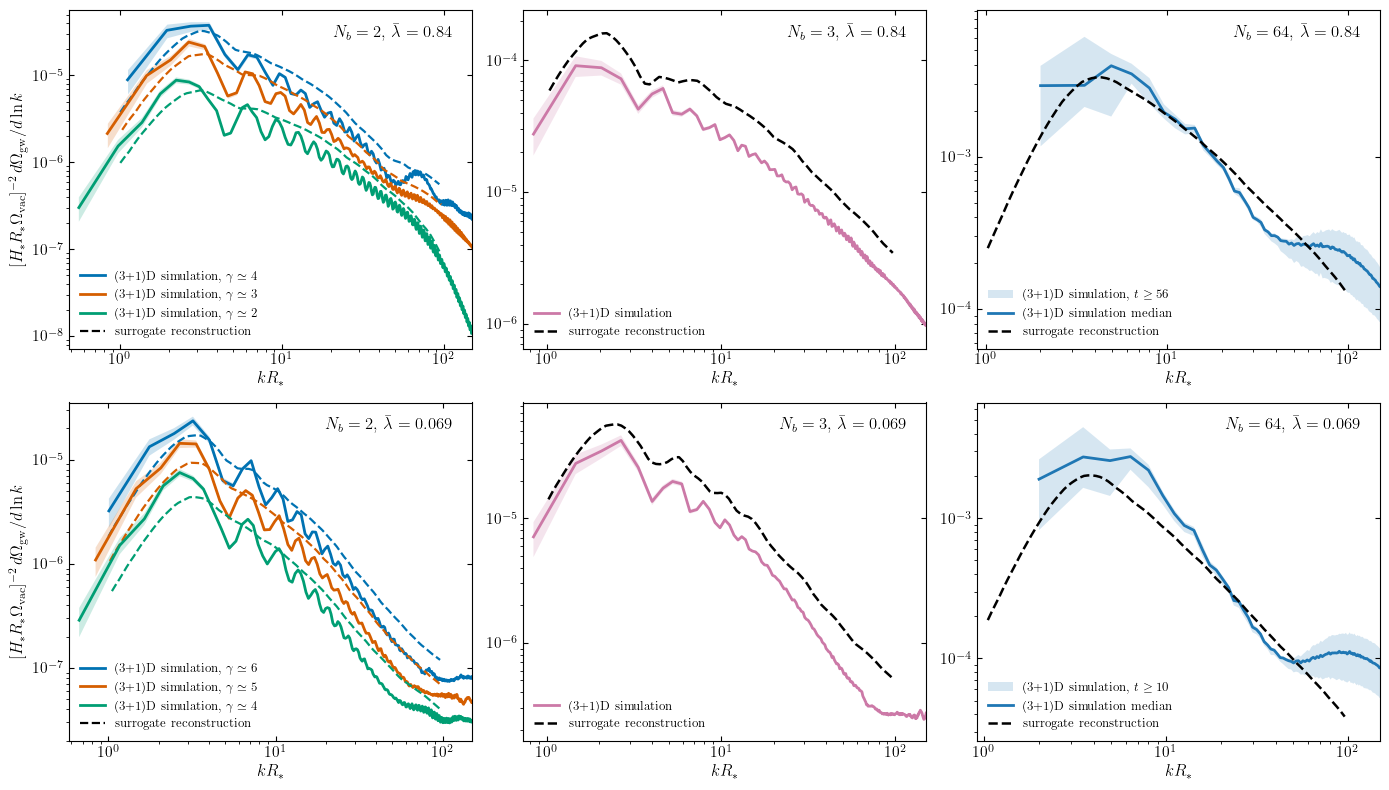

In [10]:
from matplotlib import rc, rcParams
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rcParams['text.usetex'] = True

colors_pair = ['#0072B2', '#D55E00', '#009E73']
color_3b    = '#CC79A7'
color_64    = 'C0'
RECON_COLOR = 'black'
X_MAX = 150.


def visible_extent(*xy_pairs, x_min=None, x_max=X_MAX):
    """Min/max of y (and, if x_min is None, the smallest x) across curves,
    restricted to x <= x_max -- so panel limits reflect only what's actually
    plotted, not a curve's full (possibly much wider) off-screen range."""
    ys, xmins = [], []
    for x, y in xy_pairs:
        mask = x <= x_max
        if x_min is not None:
            mask &= x >= x_min
        if mask.any():
            ys.append(y[mask])
            xmins.append(x[mask].min())
    ys = np.concatenate(ys)
    ys = ys[ys > 0]
    return min(xmins), ys.min(), ys.max()


def style_panel(ax, x_min, ymin, ymax, title):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min / 1.15, X_MAX)
    ax.set_ylim(ymin / 1.5, ymax * 1.5)
    ax.set_xlabel(r'$kR_*$', fontsize=12)
    ax.text(0.95, 0.96, title, transform=ax.transAxes, ha='right', va='top', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='lower left')
    ax.tick_params(axis='both', labelsize=11, top=True, right=True, direction='in')


fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, lb in enumerate([0.84, 0.069]):
    case = CASES[lb]

    # --- Column 1: N=2, all three gammas overlaid ------------------------
    ax = axes[row_idx, 0]
    extents = []
    for pair, color in zip(case['pairs'], colors_pair):
        r = n2_results[(lb, pair['idx'])]
        gamma = pair_gamma[(lb, pair['idx'])]
        ax.plot(r['kR_sh'], r['y_sh'], color=color, lw=2,
                label=rf'(3+1)D simulation, $\gamma\simeq{round(gamma)}$')
        ax.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr_sh'], 1e-300),
                        r['y_sh'] + r['yerr_sh'], color=color, alpha=0.2, linewidth=0)
        ax.plot(r['kR_recon'], r['y_recon'], color=color, lw=1.6, ls='--')
        extents.append(visible_extent((r['kR_sh'], r['y_sh']), (r['kR_recon'], r['y_recon'])))
    ax.plot([], [], color=RECON_COLOR, lw=1.6, ls='--', label='surrogate reconstruction')
    x_min = min(e[0] for e in extents)
    style_panel(ax, x_min, min(e[1] for e in extents), max(e[2] for e in extents),
               rf'$N_b=2$,  $\bar\lambda={lb}$')

    # --- Column 2: N=3 trio -----------------------------------------------
    ax = axes[row_idx, 1]
    r3 = n3_results[lb]
    ax.plot(r3['kR_sh'], r3['y_sh'], color=color_3b, lw=2, label='(3+1)D simulation')
    ax.fill_between(r3['kR_sh'], np.maximum(r3['y_sh'] - r3['yerr_sh'], 1e-300),
                    r3['y_sh'] + r3['yerr_sh'], color=color_3b, alpha=0.2, linewidth=0)
    ax.plot(r3['kR_recon'], r3['y_recon'], color=RECON_COLOR, lw=1.8, ls='--',
            label='surrogate reconstruction')
    x_min, ymin, ymax = visible_extent((r3['kR_sh'], r3['y_sh']), (r3['kR_recon'], r3['y_recon']))
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=3$,  $\bar\lambda={lb}$')

    # --- Column 3: N=64 ----------------------------------------------------
    ax = axes[row_idx, 2]
    r64 = n64_results[lb]
    if r64['mode'] == 'band':
        ax.fill_between(r64['kR_sh'], r64['y_min'], r64['y_max'],
                        color=color_64, alpha=0.18, linewidth=0,
                        label=rf'(3+1)D simulation, $t\geq{r64["t_range"][0]:.0f}$')
        ax.plot(r64['kR_sh'], r64['y_median'], color=color_64, lw=2,
                label='(3+1)D simulation median')
        ax.plot(r64['kR_recon'], r64['y_recon'], color=RECON_COLOR,
                lw=1.8, ls='--', label='surrogate reconstruction')
        x_min, ymin, ymax = visible_extent((r64['kR_sh'], r64['y_min']),
                                           (r64['kR_sh'], r64['y_max']),
                                           (r64['kR_recon'], r64['y_recon']))
    else:
        # Single mid-collision snapshot (lb=0.069 -- sledgehamr run goes
        # unstable before reaching a post-collision plateau, see setup cell).
        ax.plot(r64['kR_sh'], r64['y_sh'], color=color_64, lw=2,
                label=rf'(3+1)D simulation, $t/R_*={r64["t_over_rstar"]:.2f}$ (mid-collision)')
        ax.fill_between(r64['kR_sh'], np.maximum(r64['y_sh'] - r64['yerr_sh'], 1e-300),
                        r64['y_sh'] + r64['yerr_sh'], color=color_64, alpha=0.2, linewidth=0)
        ax.plot(r64['kR_recon'], r64['y_recon'], color=RECON_COLOR,
                lw=1.8, ls='--', label='surrogate reconstruction')
        x_min, ymin, ymax = visible_extent((r64['kR_sh'], r64['y_sh']),
                                           (r64['kR_recon'], r64['y_recon']))
    style_panel(ax, x_min, ymin, ymax, rf'$N_b=64$,  $\bar\lambda={lb}$')

ylabel = r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$'
axes[0, 0].set_ylabel(ylabel, fontsize=12)
axes[1, 0].set_ylabel(ylabel, fontsize=12)

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'n2n3n64_surrogate_grid.pdf', bbox_inches='tight')
plt.show()

## 5. Exploratory: N=2, N=3, N=64 combined onto a single panel per lambda_bar

Same data as the 6-panel grid above, just re-plotted with all three cases sharing one axis per $\bar\lambda$ instead of separate columns -- a quick look at whether that's legible or just busy.

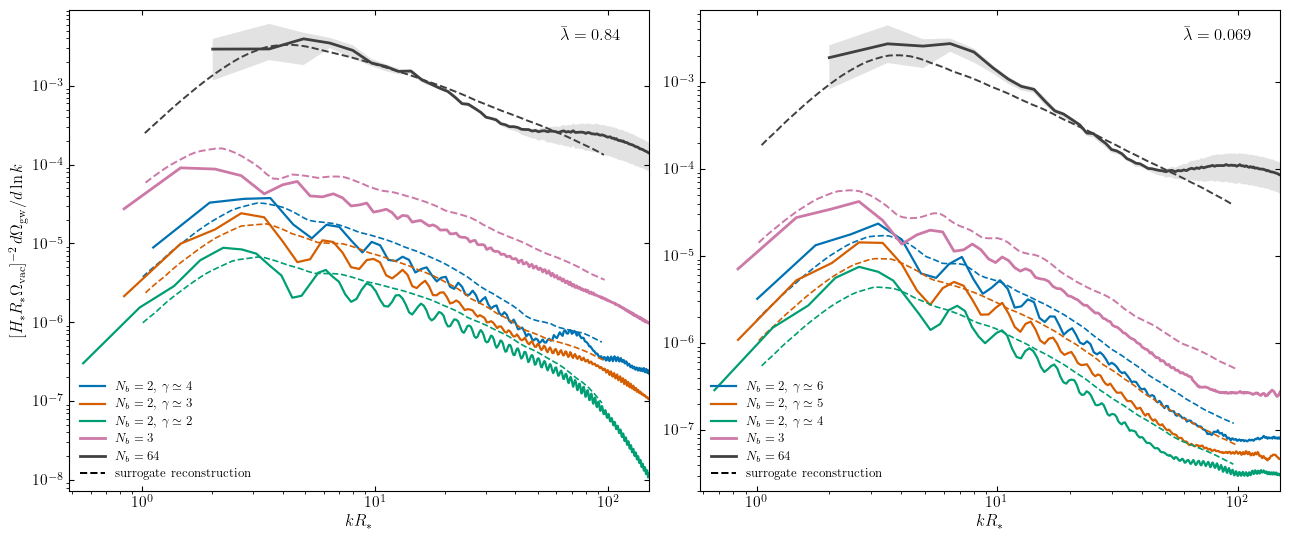

In [11]:
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5.5))

n2_colors  = colors_pair          # per-gamma, same 3 colors as the grid above
n3_color   = color_3b
n64_color  = '0.25'               # distinct from the N=2/N=3 palette

for ax, lb in zip(axes2, [0.84, 0.069]):
    case = CASES[lb]
    extents = []

    for pair, color in zip(case['pairs'], n2_colors):
        r = n2_results[(lb, pair['idx'])]
        gamma = pair_gamma[(lb, pair['idx'])]
        ax.plot(r['kR_sh'], r['y_sh'], color=color, lw=1.6,
               label=rf'$N_b=2$, $\gamma\simeq{round(gamma)}$')
        ax.plot(r['kR_recon'], r['y_recon'], color=color, lw=1.2, ls='--')
        extents.append(visible_extent((r['kR_sh'], r['y_sh']), (r['kR_recon'], r['y_recon'])))

    r3 = n3_results[lb]
    ax.plot(r3['kR_sh'], r3['y_sh'], color=n3_color, lw=2, label=r'$N_b=3$')
    ax.plot(r3['kR_recon'], r3['y_recon'], color=n3_color, lw=1.4, ls='--')
    extents.append(visible_extent((r3['kR_sh'], r3['y_sh']), (r3['kR_recon'], r3['y_recon'])))

    r64 = n64_results[lb]
    if r64['mode'] == 'band':
        ax.fill_between(r64['kR_sh'], r64['y_min'], r64['y_max'],
                        color=n64_color, alpha=0.15, linewidth=0)
        ax.plot(r64['kR_sh'], r64['y_median'], color=n64_color, lw=2, label=r'$N_b=64$')
        ax.plot(r64['kR_recon'], r64['y_recon'], color=n64_color, lw=1.4, ls='--')
        extents.append(visible_extent((r64['kR_sh'], r64['y_min']), (r64['kR_sh'], r64['y_max']),
                                      (r64['kR_recon'], r64['y_recon'])))
    else:
        ax.plot(r64['kR_sh'], r64['y_sh'], color=n64_color, lw=2, label=r'$N_b=64$')
        ax.plot(r64['kR_recon'], r64['y_recon'], color=n64_color, lw=1.4, ls='--')
        extents.append(visible_extent((r64['kR_sh'], r64['y_sh']), (r64['kR_recon'], r64['y_recon'])))

    ax.plot([], [], color=RECON_COLOR, lw=1.4, ls='--', label='surrogate reconstruction')
    x_min = min(e[0] for e in extents)
    style_panel(ax, x_min, min(e[1] for e in extents), max(e[2] for e in extents),
               rf'$\bar\lambda={lb}$')

axes2[0].set_ylabel(r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm gw}/d\ln k$', fontsize=12)

fig2.tight_layout()
fig2.savefig(PLOTS_DIR / 'n2n3n64_surrogate_combined.pdf', bbox_inches='tight')
plt.show()